<a href="https://colab.research.google.com/github/aabitokh/home_repo/blob/develop/ML/rec_sys/lstrm_recsys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
text = "Amazon,Google+,Instagram|Instagram,Evernote,Amazon,Yahoo|Evernote,Instagram,Google+"

In [ ]:
text

'Amazon,Google+,Instagram|Instagram,Evernote,Amazon,Yahoo|Evernote,Instagram,Google+'

In [ ]:
#!pip install keras_preprocessing

In [ ]:
from keras.utils import to_categorical
from keras_preprocessing.sequence import pad_sequences
from keras_preprocessing.text import Tokenizer
import numpy as np

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([text])
vocabulary_size = len(tokenizer.word_index) + 1
print('Unique items: %d' % vocabulary_size)
sequences = list()
for line in text.split('|'):
    encoded = tokenizer.texts_to_sequences([line])[0]
    sequences.append(encoded)
print('Total Sequences: %d' % len(sequences))
print(sequences)
#Output =>
#Total Sequences: 3
#[[2, 3, 1], [1, 4, 2, 5], [4, 1, 3]]

Unique items: 6
Total Sequences: 3
[[2, 3, 1], [1, 4, 2, 5], [4, 1, 3]]


In [ ]:
line

'Evernote,Instagram,Google+'

In [ ]:
sequences

[[2, 3, 1], [1, 4, 2, 5], [4, 1, 3]]

In [ ]:
max_len = max([len(seq) for seq in sequences])

sequences = pad_sequences(sequences, maxlen=max_len, padding='pre')

print(sequences)
print('Max Sequence Length: %d' % max_len)
sequences = np.array(sequences)


[[0 2 3 1]
 [1 4 2 5]
 [0 4 1 3]]
Max Sequence Length: 4


In [ ]:
X, y = sequences[:, :-1], sequences[:, -1]
print(X)

[[0 2 3]
 [1 4 2]
 [0 4 1]]


In [ ]:
y = to_categorical(y, num_classes=vocabulary_size)
print(y)

[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]]


In [ ]:
from keras import Sequential
from keras.layers import Embedding, Dropout, LSTM, Dense

model = Sequential()
model.add(Embedding(vocabulary_size, 5, input_length=max_len - 1))
model.add(Dropout(0.2))
model.add(LSTM(3))
model.add(Dropout(0.2))
model.add(Dense(vocabulary_size, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - acc: 0.0000e+00 - loss: 1.7919 - val_acc: 1.0000 - val_loss: 1.7885
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.0000e+00 - loss: 1.7903 - val_acc: 0.0000e+00 - val_loss: 1.7883
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.5000 - loss: 1.7878 - val_acc: 0.0000e+00 - val_loss: 1.7880
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.5000 - loss: 1.7860 - val_acc: 0.0000e+00 - val_loss: 1.7878
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.5000 - loss: 1.7857 - val_acc: 0.0000e+00 - val_loss: 1.7876
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.0000e+00 - loss: 1.7852 - val_acc: 0.0000e+00 - val_loss: 1.7875
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - acc: 0.0000e+00 - loss: 1.7829 - val_acc: 0.0000e+00 - val_loss: 1.7874
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 1.0000 - loss: 1.7807 - val_acc: 0.0000e+00 - val_loss: 1.7873
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

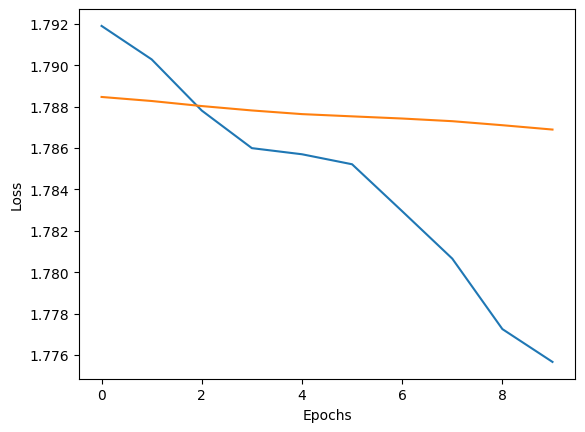

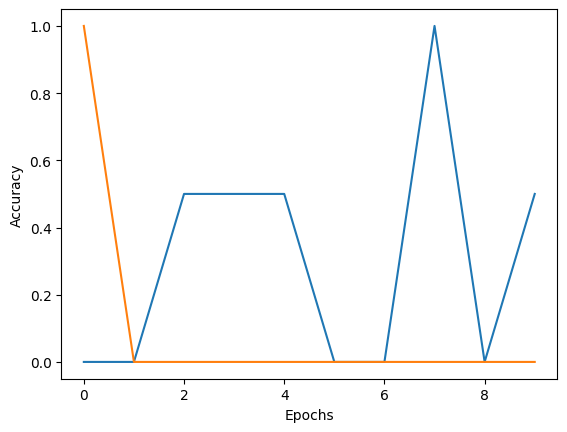

In [ ]:
h = model.fit(X, y, validation_split=0.2, verbose=1, epochs=10)
import matplotlib.pyplot as plt

plt.plot(h.history['loss'], label='Train loss')
plt.plot(h.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()
plt.plot(h.history['acc'], label='Train accuracy')
plt.plot(h.history['val_acc'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
def generate_seq(model, tokenizer, seq_length, seed_text, n_words):
    result = list()
    in_text = seed_text
    for _ in range(n_words):
        encoded = tokenizer.texts_to_sequences([in_text])[0]
        encoded = pad_sequences([encoded], maxlen=seq_length, truncating='pre')
        yhat = model.predict(encoded, verbose=0)
        # Get the index with the highest probability
        yhat = np.argmax(yhat, axis=-1) # This line is changed
        out_word = ''
        for word, index in tokenizer.word_index.items():
            if index == yhat[0]: # This line is changed to access the first element of yhat
                out_word = word
                break
        in_text += ' ' + out_word
        result.append(out_word)
    return ' '.join(result)

yahoo


In [ ]:
print(generate_seq(model, tokenizer, 6, '1 3 5', 1))

yahoo
